In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from scipy import constants
from scipy.sparse.linalg import eigsh
%matplotlib inline 

In [11]:
sigma_x = np.array(((0, 1), (1, 0)))
sigma_y = np.array(((0, -1j),(1j,0)))

In [20]:
N=4
v = 1
w = 2
H = np.zeros((2*N,2*N),dtype=complex)
for n_f in range(0,N):
    for n_c in range(0,N):
        if(n_f == n_c):
            H[(n_f*2):(n_f*2)+2,(n_c*2):(n_c*2)+2] = v*sigma_x
        if(n_f + 1 == n_c):
            H[(n_f*2):(n_f*2)+2,(n_c*2):(n_c*2)+2] = w*(sigma_x -1j*sigma_y)/2
        if(n_f == n_c + 1):
            H[(n_f*2):(n_f*2)+2,(n_c*2):(n_c*2)+2] = w*(sigma_x +1j*sigma_y)/2
H

array([[0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 2.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 2.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 2.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 2.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])

C:\Users\Gabo\Anaconda3\envs\py35\lib\site-packages\scipy\sparse\linalg\eigen\arpack\arpack.py:1254: RuntimeWarning: k >= N - 1 for N * N square matrix. Attempting to use scipy.linalg.eig instead.
  RuntimeWarning)


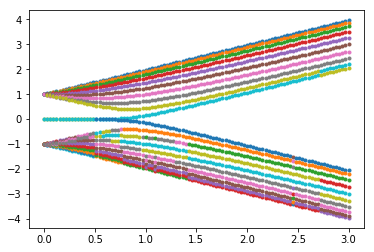

In [22]:
N=10
w = 1
for v in np.linspace(0,3,100):
    H = np.zeros((2*N,2*N),dtype=complex)
    for n_f in range(0,N):
        for n_c in range(0,N):
            if(n_f == n_c):
                H[(n_f*2):(n_f*2)+2,(n_c*2):(n_c*2)+2] = v*sigma_x
            if(n_f + 1 == n_c):
                H[(n_f*2):(n_f*2)+2,(n_c*2):(n_c*2)+2] = w*(sigma_x -1j*sigma_y)/2
            if(n_f == n_c + 1):
                H[(n_f*2):(n_f*2)+2,(n_c*2):(n_c*2)+2] = w*(sigma_x +1j*sigma_y)/2
    eigenvalues, eigenvectors = eigsh(H, k=20, which='SM')
    for g in range(0,20):
        plt.plot(v,eigenvalues[g],'.')
plt.show()